# Modelamiento predictivo - East West Airlines

Este notebook parte de la base preparada en el EDA: `output/eastwest_model_ready.csv`. Aqui no se repite la limpieza exploratoria; el foco es entrenar modelos para priorizar clientes con mayor probabilidad de comprar el servicio Telcom.

Se trabajaran tres modelos por separado:

1. **Regresion Logistica:** modelo base interpretable.
2. **Random Forest:** modelo flexible para relaciones no lineales.
3. **XGBoost:** modelo de boosting para evaluar si mejora la priorizacion comercial.


La base ya contiene las decisiones del EDA: columnas estandarizadas, 2 filas sin identificador ni resultado de compra eliminadas, tipos corregidos y outliers conservados. El identificador se mantiene solo para trazabilidad y no se usa como predictor.

In [1]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from xgboost import XGBClassifier

pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)

In [2]:
# Cargar base preparada desde el EDA
df_model = pd.read_csv('../output/eastwest_model_ready.csv')

id_col = 'id'
target_col = 'phone_sale'

variable_labels = {
    'topflight': 'Estatus elite Topflight',
    'balance': 'Millas disponibles para premios',
    'qual_miles': 'Millas calificables para Topflight',
    'cc1_miles': 'Uso de tarjeta frequent flyer',
    'cc2_miles': 'Uso de tarjeta Rewards',
    'cc3_miles': 'Uso de tarjeta Small Business',
    'bonus_miles': 'Millas por bonos no-vuelo',
    'bonus_trans': 'Transacciones bono no-vuelo',
    'flight_miles_12mo': 'Millas voladas ultimos 12 meses',
    'flight_trans_12': 'Vuelos ultimos 12 meses',
    'online_12': 'Compras online ultimos 12 meses',
    'email': 'Email registrado',
    'club_member': 'Miembro del club de la aerolinea',
    'any_cc_miles_12mo': 'Acumulo millas con alguna tarjeta',
    'phone_sale': 'Compra del servicio Telcom'
}

feature_cols = [col for col in df_model.columns if col not in [id_col, target_col]]

print('Filas para modelamiento:', df_model.shape[0])
print('Variables predictoras:', len(feature_cols))
print('Tasa base de compra Telcom: {:.2f}%'.format(df_model[target_col].mean() * 100))

Filas para modelamiento: 4985
Variables predictoras: 14
Tasa base de compra Telcom: 20.90%


## 0.1 Definicion de X, y y revision del desbalance

Se define una sola matriz de variables predictoras y una sola variable objetivo para todos los modelos. Esto asegura que la comparacion final sea justa.

In [3]:
# Definir X e y una sola vez
X = df_model[feature_cols]
y = df_model[target_col].astype(int)

# Revisar desbalance de clases
desbalance = (
    y.value_counts()
    .rename_axis('compra_telcom')
    .reset_index(name='clientes')
)
desbalance['resultado'] = desbalance['compra_telcom'].map({0: 'No compro', 1: 'Compro'})
desbalance['porcentaje'] = (desbalance['clientes'] / len(y) * 100).round(2)
desbalance = desbalance[['resultado', 'clientes', 'porcentaje']]

display(desbalance)

,resultado,clientes,porcentaje
0,No compro,3943,79.1000
1,Compro,1042,20.9000


**Hallazgo:** la compra del servicio Telcom esta desbalanceada: aproximadamente 21% compro y 79% no compro. Por eso los modelos se evaluaran con ROC-AUC, PR-AUC, recall, precision, F1-score y lift comercial; no solo con accuracy.

## 0.2 Alerta de variable dominante: miembro del club

En el EDA se observo que la pertenencia al club tiene una relacion muy fuerte con la compra Telcom. Antes de modelar, se revisa esta variable porque puede aportar mucho valor, pero tambien debe validarse con negocio para confirmar que estaba disponible antes de la campana.

In [4]:
# Revisar compra Telcom segun pertenencia al club
club_alerta = (
    df_model.groupby('club_member')[target_col]
    .agg(clientes='count', tasa_compra_telcom='mean')
    .assign(tasa_compra_telcom=lambda x: (x['tasa_compra_telcom'] * 100).round(2))
    .reset_index()
    .rename(columns={'club_member': 'miembro_club'})
)

display(club_alerta)

,miembro_club,clientes,tasa_compra_telcom
0,0,4528,12.9200
1,1,457,100.0000


**Decision:** se mantiene `club_member` en los modelos porque es una variable original disponible en la base y tiene valor predictivo. Sin embargo, queda marcada como variable critica: antes de usar el modelo en produccion, negocio debe confirmar que esta informacion existe antes de contactar al cliente y no fue creada como resultado de la campana.

## 0.3 Split unico train-test

Se usa un unico split estratificado para los tres modelos. Asi todos se entrenan y prueban sobre exactamente los mismos clientes.

In [5]:
# Split unico para todos los modelos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Train:', X_train.shape[0], 'clientes')
print('Test :', X_test.shape[0], 'clientes')
print('Tasa compra train: {:.2f}%'.format(y_train.mean() * 100))
print('Tasa compra test : {:.2f}%'.format(y_test.mean() * 100))

Train: 3988 clientes
Test : 997 clientes
Tasa compra train: 20.91%
Tasa compra test : 20.86%


In [6]:
# Funciones de evaluacion reutilizables
resultados_individuales = {}
probabilidades_modelos = {}


def calcular_lift_por_top(y_test, y_prob, cortes=(0.10, 0.20, 0.30)):
    tasa_base = y_test.mean()
    filas = []

    for corte in cortes:
        top_n = int(np.ceil(len(y_test) * corte))
        top_idx = np.argsort(y_prob)[-top_n:]
        tasa_top = y_test.iloc[top_idx].mean()
        filas.append({
            'top_pct': int(corte * 100),
            'clientes_contactados': top_n,
            'tasa_compra_top': tasa_top,
            'lift': tasa_top / tasa_base if tasa_base > 0 else np.nan
        })

    return pd.DataFrame(filas)


def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = modelo.predict(X_test)
    tasa_base = y_test.mean()
    lift_por_top = calcular_lift_por_top(y_test, y_prob)

    metricas = {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'brier_score': brier_score_loss(y_test, y_prob),
        'tasa_base_test': tasa_base
    }

    for _, fila in lift_por_top.iterrows():
        top_pct = int(fila['top_pct'])
        metricas[f'tasa_compra_top_{top_pct}'] = fila['tasa_compra_top']
        metricas[f'lift_top_{top_pct}'] = fila['lift']

    return metricas, y_pred, y_prob


def mostrar_metricas(metricas):
    tabla = pd.DataFrame([metricas])
    pct_cols = [
        'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc',
        'tasa_base_test', 'tasa_compra_top_10', 'tasa_compra_top_20', 'tasa_compra_top_30'
    ]
    for col in pct_cols:
        if col in tabla.columns:
            tabla[col] = (tabla[col] * 100).round(2)

    tabla['brier_score'] = tabla['brier_score'].round(4)
    for col in ['lift_top_10', 'lift_top_20', 'lift_top_30']:
        if col in tabla.columns:
            tabla[col] = tabla[col].round(2)

    display(tabla)


# 1. Regresion Logistica

La Regresion Logistica se usa como modelo base porque es interpretable y permite tener un primer punto de comparacion para la priorizacion comercial.

## 1.1 Pipeline y escalamiento

Este modelo requiere escalamiento porque sus coeficientes dependen de la escala de las variables. El pipeline imputa posibles nulos con mediana, escala las variables y entrena con `class_weight='balanced'` por el desbalance de clases.

In [7]:
# Pipeline de Regresion Logistica
logit_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ))
])

## 1.2 Entrenamiento

In [8]:
# Entrenar Regresion Logistica
logit_model.fit(X_train, y_train)
print('Regresion Logistica entrenada')

Regresion Logistica entrenada


## 1.3 Prediccion y evaluacion en test

In [9]:
# Evaluar Regresion Logistica
metricas_logit, y_pred_logit, y_prob_logit = evaluar_modelo(
    'Regresion Logistica',
    logit_model,
    X_test,
    y_test
)
resultados_individuales['Regresion Logistica'] = metricas_logit
probabilidades_modelos['Regresion Logistica'] = y_prob_logit
mostrar_metricas(metricas_logit)

print(classification_report(
    y_test,
    y_pred_logit,
    target_names=['No compro Telcom', 'Compro Telcom'],
    zero_division=0
))

,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc,brier_score,tasa_base_test,tasa_compra_top_10,lift_top_10,tasa_compra_top_20,lift_top_20,tasa_compra_top_30,lift_top_30
0,Regresion Logistica,82.8500,61.2100,48.5600,54.1600,76.4900,64.9100,0.1485,20.8600,92.0000,4.4100,52.5000,2.5200,40.3300,1.9300


                  precision    recall  f1-score   support

No compro Telcom       0.87      0.92      0.89       789
   Compro Telcom       0.61      0.49      0.54       208

        accuracy                           0.83       997
       macro avg       0.74      0.70      0.72       997
    weighted avg       0.82      0.83      0.82       997



**Hallazgo:** la Regresion Logistica alcanza un ROC-AUC cercano a 76.5% y duplica aproximadamente la tasa base en el top 30% priorizado: 40.3% de compra frente a 20.9% del promedio. Es un buen baseline porque prioriza mejor que una campana general y mantiene interpretabilidad.

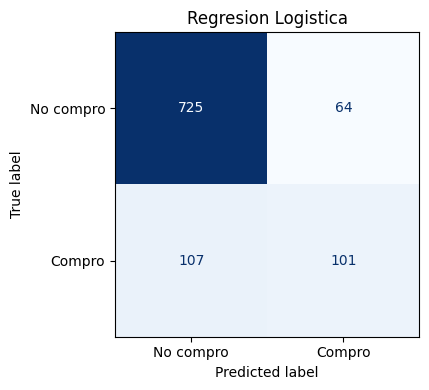

In [10]:
# Matriz de confusion - Regresion Logistica
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logit,
    display_labels=['No compro', 'Compro'],
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Regresion Logistica')
plt.tight_layout()
plt.show()

In [11]:
# Coeficientes de Regresion Logistica
coef_logit = pd.DataFrame({
    'variable': feature_cols,
    'descripcion': [variable_labels[col] for col in feature_cols],
    'coeficiente': logit_model.named_steps['model'].coef_[0]
})
coef_logit['abs_coeficiente'] = coef_logit['coeficiente'].abs()
coef_logit = coef_logit.sort_values('abs_coeficiente', ascending=False)

display(coef_logit[['descripcion', 'coeficiente']].head(10))

,descripcion,coeficiente
12,Miembro del club de la aerolinea,2.4361
13,Acumulo millas con alguna tarjeta,0.3584
7,Transacciones bono no-vuelo,0.3136
1,Millas disponibles para premios,-0.2978
11,Email registrado,0.1245
8,Millas voladas ultimos 12 meses,0.1119
2,Millas calificables para Topflight,-0.0845
9,Vuelos ultimos 12 meses,-0.0814
10,Compras online ultimos 12 meses,0.0563
3,Uso de tarjeta frequent flyer,-0.0554


# 2. Random Forest

Random Forest se usa porque puede capturar relaciones no lineales entre fidelizacion, millas, tarjetas y actividad reciente. No requiere escalamiento.

## 2.1 Pipeline

El pipeline imputa posibles nulos con mediana y entrena el modelo con `class_weight='balanced'` para considerar el desbalance de clases.

In [12]:
# Pipeline de Random Forest
rf_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

## 2.2 Entrenamiento

In [13]:
# Entrenar Random Forest
rf_model.fit(X_train, y_train)
print('Random Forest entrenado')

Random Forest entrenado


## 2.3 Prediccion y evaluacion en test

In [14]:
# Evaluar Random Forest
metricas_rf, y_pred_rf, y_prob_rf = evaluar_modelo(
    'Random Forest',
    rf_model,
    X_test,
    y_test
)
resultados_individuales['Random Forest'] = metricas_rf
probabilidades_modelos['Random Forest'] = y_prob_rf
mostrar_metricas(metricas_rf)

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['No compro Telcom', 'Compro Telcom'],
    zero_division=0
))

,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc,brier_score,tasa_base_test,tasa_compra_top_10,lift_top_10,tasa_compra_top_20,lift_top_20,tasa_compra_top_30,lift_top_30
0,Random Forest,86.0600,75.9400,48.5600,59.2400,77.7100,65.9200,0.1483,20.8600,89.0000,4.2700,54.5000,2.6100,40.6700,1.9500


                  precision    recall  f1-score   support

No compro Telcom       0.88      0.96      0.92       789
   Compro Telcom       0.76      0.49      0.59       208

        accuracy                           0.86       997
       macro avg       0.82      0.72      0.75       997
    weighted avg       0.85      0.86      0.85       997



**Hallazgo:** Random Forest mejora el baseline en ROC-AUC, precision y F1-score. Mantiene una tasa de compra de 40.7% en el top 30% priorizado, casi el doble de la tasa base. Su principal ventaja es reducir falsos positivos frente a Regresion Logistica, aunque con recall similar.

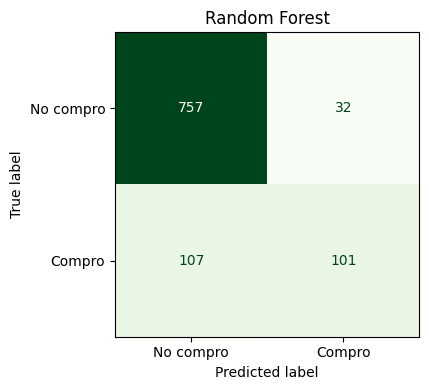

In [15]:
# Matriz de confusion - Random Forest
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No compro', 'Compro'],
    cmap='Greens',
    colorbar=False,
    ax=ax
)
ax.set_title('Random Forest')
plt.tight_layout()
plt.show()

,descripcion,importancia
12,Miembro del club de la aerolinea,0.5901
6,Millas por bonos no-vuelo,0.1050
7,Transacciones bono no-vuelo,0.0847
1,Millas disponibles para premios,0.0830
8,Millas voladas ultimos 12 meses,0.0344
9,Vuelos ultimos 12 meses,0.0280
13,Acumulo millas con alguna tarjeta,0.0198
3,Uso de tarjeta frequent flyer,0.0133
0,Estatus elite Topflight,0.0122
2,Millas calificables para Topflight,0.0100


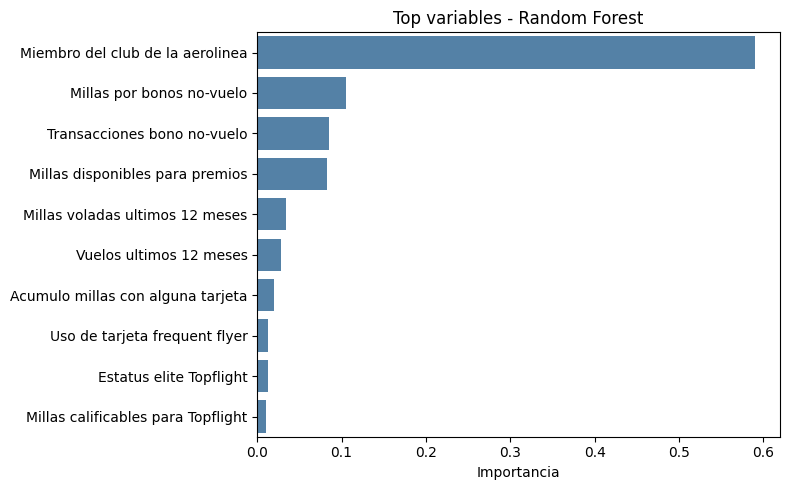

In [16]:
# Importancia de variables en Random Forest
rf_importance = pd.DataFrame({
    'variable': feature_cols,
    'descripcion': [variable_labels[col] for col in feature_cols],
    'importancia': rf_model.named_steps['model'].feature_importances_
}).sort_values('importancia', ascending=False)

display(rf_importance[['descripcion', 'importancia']].head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance.head(10), y='descripcion', x='importancia', color='steelblue')
plt.title('Top variables - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 3. XGBoost

XGBoost se agrega como tercer modelo porque suele funcionar bien en datos tabulares y puede mejorar el ranking de clientes con mayor probabilidad de compra. Se compara contra los dos modelos anteriores para verificar si la mayor complejidad aporta valor comercial.

## 3.1 Pipeline

XGBoost no requiere escalamiento. Se usa `scale_pos_weight` para compensar el desbalance entre no compradores y compradores dentro del set de entrenamiento.

In [17]:
# Calcular peso de clase positiva para XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Pipeline de XGBoost
xgb_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

## 3.2 Entrenamiento

In [18]:
# Entrenar XGBoost
xgb_model.fit(X_train, y_train)
print('XGBoost entrenado')

XGBoost entrenado


## 3.3 Prediccion y evaluacion en test

In [19]:
# Evaluar XGBoost
metricas_xgb, y_pred_xgb, y_prob_xgb = evaluar_modelo(
    'XGBoost',
    xgb_model,
    X_test,
    y_test
)
resultados_individuales['XGBoost'] = metricas_xgb
probabilidades_modelos['XGBoost'] = y_prob_xgb
mostrar_metricas(metricas_xgb)

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['No compro Telcom', 'Compro Telcom'],
    zero_division=0
))

,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc,brier_score,tasa_base_test,tasa_compra_top_10,lift_top_10,tasa_compra_top_20,lift_top_20,tasa_compra_top_30,lift_top_30
0,XGBoost,81.8500,57.3800,50.4800,53.7100,77.1800,65.6000,0.1474,20.8600,90.0000,4.3100,55.5000,2.6600,42.3300,2.0300


                  precision    recall  f1-score   support

No compro Telcom       0.87      0.90      0.89       789
   Compro Telcom       0.57      0.50      0.54       208

        accuracy                           0.82       997
       macro avg       0.72      0.70      0.71       997
    weighted avg       0.81      0.82      0.81       997



**Hallazgo:** XGBoost logra la mayor tasa de compra en el top 30% priorizado: 42.3%, equivalente a un lift de 2.03 frente a la tasa base. Sin embargo, su precision y F1-score son menores que Random Forest, por lo que su valor estaria mas en ranking comercial que en clasificacion con umbral 0.50.

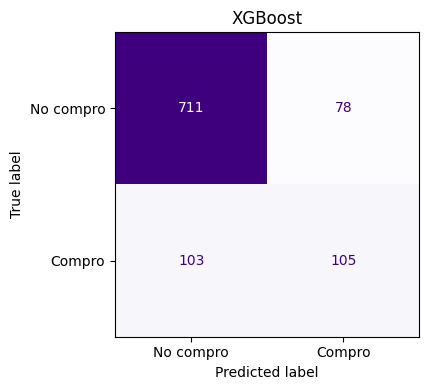

In [20]:
# Matriz de confusion - XGBoost
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=['No compro', 'Compro'],
    cmap='Purples',
    colorbar=False,
    ax=ax
)
ax.set_title('XGBoost')
plt.tight_layout()
plt.show()

In [21]:
# Importancia de variables en XGBoost
xgb_importance = pd.DataFrame({
    'variable': feature_cols,
    'descripcion': [variable_labels[col] for col in feature_cols],
    'importancia': xgb_model.named_steps['model'].feature_importances_
}).sort_values('importancia', ascending=False)

display(xgb_importance[['descripcion', 'importancia']].head(10))

,descripcion,importancia
12,Miembro del club de la aerolinea,0.5688
13,Acumulo millas con alguna tarjeta,0.0661
6,Millas por bonos no-vuelo,0.0558
7,Transacciones bono no-vuelo,0.0432
3,Uso de tarjeta frequent flyer,0.0415
1,Millas disponibles para premios,0.0296
11,Email registrado,0.0279
0,Estatus elite Topflight,0.0263
9,Vuelos ultimos 12 meses,0.0254
4,Uso de tarjeta Rewards,0.0252


# 4. Comparacion final de modelos

Despues de evaluar cada modelo por separado, se comparan con las mismas particiones de train-test. Para negocio, la metrica clave no es solo accuracy, sino la capacidad de priorizar clientes con mayor probabilidad de compra Telcom.

In [22]:
# Tabla comparativa final
comparacion_modelos = pd.DataFrame(resultados_individuales.values()).sort_values('roc_auc', ascending=False)

comparacion_modelos_mostrar = comparacion_modelos.copy()
pct_cols = [
    'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc',
    'tasa_base_test', 'tasa_compra_top_10', 'tasa_compra_top_20', 'tasa_compra_top_30'
]
for col in pct_cols:
    comparacion_modelos_mostrar[col] = (comparacion_modelos_mostrar[col] * 100).round(2)
comparacion_modelos_mostrar['brier_score'] = comparacion_modelos_mostrar['brier_score'].round(4)
for col in ['lift_top_10', 'lift_top_20', 'lift_top_30']:
    comparacion_modelos_mostrar[col] = comparacion_modelos_mostrar[col].round(2)

columnas_comparacion = [
    'modelo', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc',
    'brier_score', 'tasa_base_test', 'tasa_compra_top_10', 'lift_top_10',
    'tasa_compra_top_20', 'lift_top_20', 'tasa_compra_top_30', 'lift_top_30'
]
display(comparacion_modelos_mostrar[columnas_comparacion])


,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc,brier_score,tasa_base_test,tasa_compra_top_10,lift_top_10,tasa_compra_top_20,lift_top_20,tasa_compra_top_30,lift_top_30
1,Random Forest,86.0600,75.9400,48.5600,59.2400,77.7100,65.9200,0.1483,20.8600,89.0000,4.2700,54.5000,2.6100,40.6700,1.9500
2,XGBoost,81.8500,57.3800,50.4800,53.7100,77.1800,65.6000,0.1474,20.8600,90.0000,4.3100,55.5000,2.6600,42.3300,2.0300
0,Regresion Logistica,82.8500,61.2100,48.5600,54.1600,76.4900,64.9100,0.1485,20.8600,92.0000,4.4100,52.5000,2.5200,40.3300,1.9300


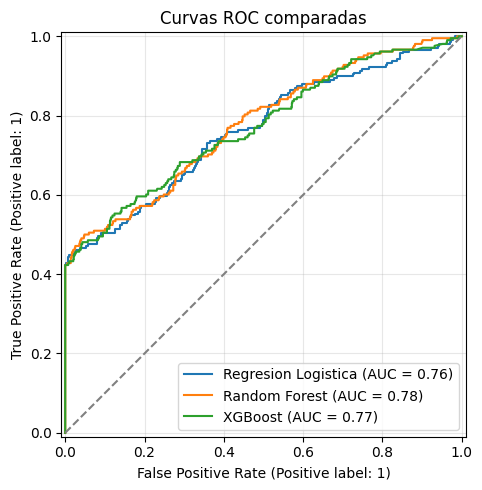

In [23]:
# Curvas ROC comparadas
fig, ax = plt.subplots(figsize=(7, 5))
for nombre, y_prob in probabilidades_modelos.items():
    RocCurveDisplay.from_predictions(y_test, y_prob, name=nombre, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')
ax.set_title('Curvas ROC comparadas')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Random Forest es el modelo mas equilibrado por precision, F1-score y ROC-AUC. XGBoost compite mejor cuando el criterio principal es priorizar clientes en los primeros cortes de campana, especialmente si se revisa el top 10%, top 20% y top 30%. Por eso, la seleccion final depende del objetivo operativo: equilibrio general con Random Forest o mayor foco en ranking comercial con XGBoost.


## 4.1 Experimento de sensibilidad sin `club_member`

La pertenencia al club es la variable mas dominante en los tres modelos. Como los miembros del club muestran 100% de compra Telcom en la muestra, se entrena una segunda version sin `club_member`. Este experimento no reemplaza el modelo principal; sirve para medir cuanto depende el desempeno de una variable que negocio debe validar antes de produccion.


In [24]:
# Crear una segunda matriz de variables sin club_member
feature_cols_sin_club = [col for col in feature_cols if col != 'club_member']

X_sin_club = df_model[feature_cols_sin_club]

X_train_sin_club, X_test_sin_club, y_train_sin_club, y_test_sin_club = train_test_split(
    X_sin_club,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Variables predictoras con club_member:', len(feature_cols))
print('Variables predictoras sin club_member:', len(feature_cols_sin_club))
print('Train sin club:', X_train_sin_club.shape[0], 'clientes')
print('Test sin club :', X_test_sin_club.shape[0], 'clientes')


Variables predictoras con club_member: 14
Variables predictoras sin club_member: 13
Train sin club: 3988 clientes
Test sin club : 997 clientes


In [25]:
# Pipelines equivalentes para comparar sin club_member
logit_sin_club = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ))
])

rf_sin_club = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

scale_pos_weight_sin_club = (y_train_sin_club == 0).sum() / (y_train_sin_club == 1).sum()
xgb_sin_club = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight_sin_club,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])


In [26]:
# Entrenar y evaluar modelos sin club_member
modelos_sin_club = {
    'Regresion Logistica sin club_member': logit_sin_club,
    'Random Forest sin club_member': rf_sin_club,
    'XGBoost sin club_member': xgb_sin_club
}

resultados_sin_club = {}
probabilidades_sin_club = {}

for nombre, modelo in modelos_sin_club.items():
    modelo.fit(X_train_sin_club, y_train_sin_club)
    metricas, y_pred, y_prob = evaluar_modelo(nombre, modelo, X_test_sin_club, y_test_sin_club)
    resultados_sin_club[nombre] = metricas
    probabilidades_sin_club[nombre] = y_prob

comparacion_sin_club = pd.DataFrame(resultados_sin_club.values()).sort_values('roc_auc', ascending=False)
comparacion_sin_club_mostrar = comparacion_sin_club.copy()
for col in pct_cols:
    comparacion_sin_club_mostrar[col] = (comparacion_sin_club_mostrar[col] * 100).round(2)
comparacion_sin_club_mostrar['brier_score'] = comparacion_sin_club_mostrar['brier_score'].round(4)
for col in ['lift_top_10', 'lift_top_20', 'lift_top_30']:
    comparacion_sin_club_mostrar[col] = comparacion_sin_club_mostrar[col].round(2)

display(comparacion_sin_club_mostrar[columnas_comparacion])


,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc,brier_score,tasa_base_test,tasa_compra_top_10,lift_top_10,tasa_compra_top_20,lift_top_20,tasa_compra_top_30,lift_top_30
0,Regresion Logistica sin club_member,58.7800,27.2900,58.6500,37.2500,63.0900,32.1500,0.2349,20.8600,42.0000,2.0100,32.5000,1.5600,29.0000,1.3900
1,Random Forest sin club_member,59.3800,26.7100,54.3300,35.8200,60.7900,30.2200,0.2205,20.8600,43.0000,2.0600,27.5000,1.3200,26.6700,1.2800
2,XGBoost sin club_member,56.6700,24.0700,50.0000,32.5000,58.7300,28.2600,0.2314,20.8600,35.0000,1.6800,27.0000,1.2900,24.6700,1.1800


In [27]:
# Comparar escenarios con y sin club_member
comparacion_modelos_escenario = comparacion_modelos.assign(escenario='Con club_member')
comparacion_sin_club_escenario = comparacion_sin_club.assign(escenario='Sin club_member')

comparacion_escenarios = pd.concat(
    [comparacion_modelos_escenario, comparacion_sin_club_escenario],
    ignore_index=True
)
comparacion_escenarios_mostrar = comparacion_escenarios.copy()
for col in pct_cols:
    comparacion_escenarios_mostrar[col] = (comparacion_escenarios_mostrar[col] * 100).round(2)
comparacion_escenarios_mostrar['brier_score'] = comparacion_escenarios_mostrar['brier_score'].round(4)
for col in ['lift_top_10', 'lift_top_20', 'lift_top_30']:
    comparacion_escenarios_mostrar[col] = comparacion_escenarios_mostrar[col].round(2)

columnas_escenario = ['escenario'] + columnas_comparacion
display(comparacion_escenarios_mostrar[columnas_escenario].sort_values(['escenario', 'roc_auc'], ascending=[True, False]))


,escenario,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc,brier_score,tasa_base_test,tasa_compra_top_10,lift_top_10,tasa_compra_top_20,lift_top_20,tasa_compra_top_30,lift_top_30
0,Con club_member,Random Forest,86.0600,75.9400,48.5600,59.2400,77.7100,65.9200,0.1483,20.8600,89.0000,4.2700,54.5000,2.6100,40.6700,1.9500
1,Con club_member,XGBoost,81.8500,57.3800,50.4800,53.7100,77.1800,65.6000,0.1474,20.8600,90.0000,4.3100,55.5000,2.6600,42.3300,2.0300
2,Con club_member,Regresion Logistica,82.8500,61.2100,48.5600,54.1600,76.4900,64.9100,0.1485,20.8600,92.0000,4.4100,52.5000,2.5200,40.3300,1.9300
3,Sin club_member,Regresion Logistica sin club_member,58.7800,27.2900,58.6500,37.2500,63.0900,32.1500,0.2349,20.8600,42.0000,2.0100,32.5000,1.5600,29.0000,1.3900
4,Sin club_member,Random Forest sin club_member,59.3800,26.7100,54.3300,35.8200,60.7900,30.2200,0.2205,20.8600,43.0000,2.0600,27.5000,1.3200,26.6700,1.2800
5,Sin club_member,XGBoost sin club_member,56.6700,24.0700,50.0000,32.5000,58.7300,28.2600,0.2314,20.8600,35.0000,1.6800,27.0000,1.2900,24.6700,1.1800


**Lectura del experimento:** si negocio confirma que `club_member` estaba disponible antes de la campana, el escenario con esa variable es valido y puede aprovecharse. Si no se puede confirmar, el escenario sin `club_member` es la referencia mas prudente para evitar fuga de informacion. La recomendacion final debe considerar ambos resultados.


# Conclusiones finales

- **Random Forest** es el modelo mas equilibrado cuando se consideran metricas generales como accuracy, precision, F1-score y ROC-AUC.

- **XGBoost** queda como alternativa fuerte cuando el objetivo operativo es priorizar clientes por probabilidad de compra, porque puede mejorar los cortes superiores de la lista comercial.

- La evaluacion por **top 10%, top 20% y top 30%** permite conectar el modelo con decisiones reales de campana: cuantos clientes se contactan y que tasa de compra se espera en cada corte.

- La variable **club_member** debe validarse con negocio. En la muestra, todos los miembros del club compraron Telcom, por lo que puede ser una senal comercial muy valiosa o una posible fuga de informacion.

- Si `club_member` estaba disponible antes de la campana, el escenario con esa variable es defendible. Si no se puede asegurar, debe usarse el experimento sin `club_member` como referencia mas conservadora.

- Desde el punto de vista de negocio, el modelo debe usarse para **priorizar contactos comerciales**, no solo para clasificar clientes.
